In [5]:
import os
import numpy as np
import pandas as pd
import cv2
import random
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
# config
DATA_DIR = "/kaggle/input/datasets/alenjakopli/sky-images-and-solar-radiation-measurement-dataset"
IMG_SIZE = 128
MAX_IMAGES = 5000

In [7]:
# load image paths
image_paths = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(".jpg") or file.endswith(".png"):
            image_paths.append(os.path.join(root, file))

print("Total images found:", len(image_paths))

# Shuffle and take subset
random.shuffle(image_paths)
image_paths = image_paths[:MAX_IMAGES]

print("Using images:", len(image_paths))

Total images found: 381805
Using images: 5000


In [8]:
# extract lable
def extract_irradiance(filename):
    try:
        value = filename.split("_")[-1].split(".")[0]
        return float(value)
    except:
        return None

In [9]:
# load images and labels
X = []
y = []

for path in tqdm(image_paths):
    img = cv2.imread(path)
    if img is None:
        continue
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    
    label = extract_irradiance(os.path.basename(path))
    
    if label is None:
        continue
    
    X.append(img)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Final dataset:", X.shape, y.shape)

100%|██████████| 5000/5000 [01:30<00:00, 55.50it/s]


Final dataset: (4978, 128, 128, 3) (4978,)


In [10]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# build CNN model
model = models.Sequential([
    
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1)
])

In [15]:
# compile model
model.compile(
    optimizer='adam',
    loss='mse',     # because you're doing regression
    metrics=['mae']
)

# build model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 526ms/step - loss: 44.7087 - mae: 5.1983 - val_loss: 22.2830 - val_mae: 3.4316
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 546ms/step - loss: 24.5508 - mae: 3.6766 - val_loss: 15.9180 - val_mae: 2.4808
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 527ms/step - loss: 17.2005 - mae: 2.8811 - val_loss: 13.8237 - val_mae: 2.4298
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 61s 546ms/step - loss: 12.2465 - mae: 2.4159 - val_loss: 10.4998 - val_mae: 2.3203
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 528ms/step - loss: 13.4312 - mae: 2.5322 - val_loss: 7.3145 - val_mae: 1.8701
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 59s 531ms/step - loss: 10.2667 - mae: 2.1893 - val_loss: 6.7836 - val_mae: 1.8499
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 58s 513ms/step - loss: 8.1454 - mae: 1.9250 - val_loss: 5.0350 - val_mae: 1.5331
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 58s 519ms/step - loss: 8.5443 - mae: 1.9408 - val_loss: 4.6417 - val_mae: 1.4587
Epoch 9/10
112/112 ━━━

In [16]:
# evaluation
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("RMSE:", rmse)
print("R2 Score:", r2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step
RMSE: 2.37765380716211
R2 Score: 0.8580733597667525


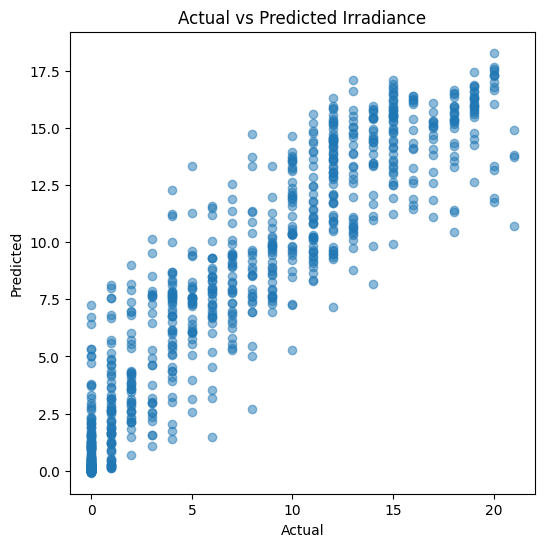

In [17]:
# visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Irradiance")
plt.show()

The CNN model demonstrates a clear positive correlation between predicted and actual irradiance values, indicating successful learning of visual atmospheric patterns. However, the dispersion of predictions around the ideal diagonal line reveals moderate prediction error, particularly at higher irradiance levels where the model tends to underestimate values. This suggests that while sky images capture cloud morphology effectively, they may not fully represent all factors influencing solar irradiance, such as atmospheric conditions and temporal dependencies.

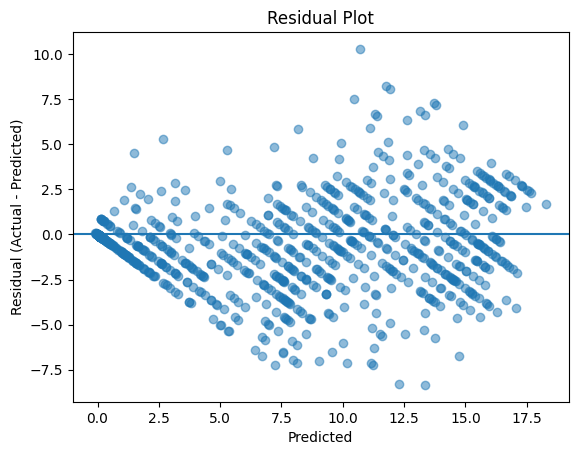

In [18]:
residuals = y_test - preds.flatten()

plt.scatter(preds, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()
# Residuals show non-random patterns at higher irradiance levels, indicating model bias and reduced accuracy under high-intensity solar conditions.

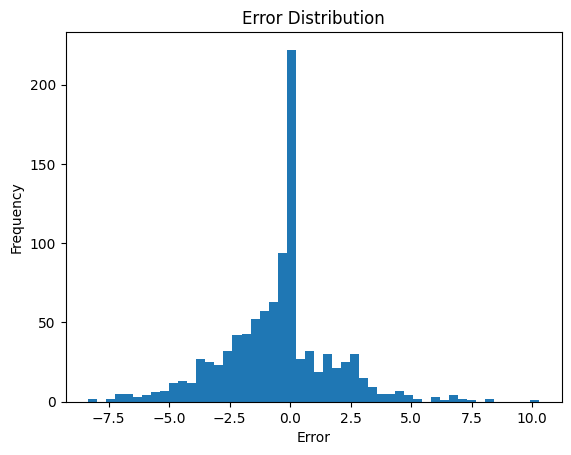

In [19]:
plt.hist(residuals, bins=50)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()
# Error distribution is centered near zero but exhibits slight skewness, indicating minor systematic underestimation.

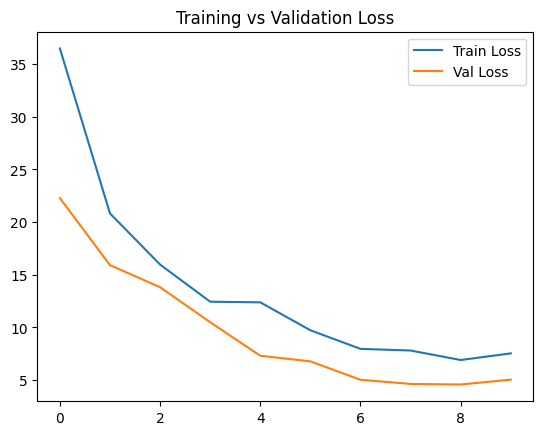

In [20]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# The training and validation loss curves remain close, indicating controlled overfitting, though overall loss suggests moderate underfitting